# 07_02 How large is the refit noise floor?

Every batch result in `06_01`, `06_02` and `07_01` comes from a **single seed**. Their
claimed effects are:

| Batch | Claimed row-WAPE effect |
| --- | ---: |
| `06_01` raw temperature anomaly | −0.115 pp |
| `06_02` article temperature sensitivity | −0.650 pp |
| `07_01` Bundesland calendar fix | +0.018 pp (bias −0.543 pp) |

None of these can be interpreted without knowing how much the metric moves when *nothing*
changes. There were two warning signs that the answer is "not negligible":

- `06_01` reshuffled gain share by ±5 pp on features that had nothing to do with the batch
  (`rolling_28_demand_rate` −5.75, `action_on_forecast_day` −5.66, `demand_rate_last_24`
  +5.43).
- The `07_01` baseline fit scored −0.605 relative bias where `06_02`, on the **same data**,
  scored −0.973 — a 0.368 pp swing across what should have been a near-identical model.

Neither is a clean measurement: both confound a code change with the randomness. This
notebook measures the randomness on its own.

## Design

Five fits of the **identical** configuration — same features, same rows, same
hyperparameters, same 20 evaluation origins — differing only in `RuntimeConfig.random_state`,
which seeds LightGBM's `seed`, `feature_fraction_seed` and `bagging_seed`.

- Dataset: `data/processed/transactions_fixed`, the corrected data that `07_01` established
  as the one to carry forward. Measuring the noise floor of a retired dataset would be
  pointless.
- Seeds: **42** (the published `run_fixed_data` fit) plus **7, 13, 101, 202**.
- `FEATURE_BUILDER_VERSION` is untouched, so all five runs reuse the same 72 cached feature
  partitions. Nothing but the boosting randomness differs.

## What the result decides

- **sd ≲ 0.1 pp** — `06_02`'s −0.650 pp is unambiguous, `06_01`'s −0.115 pp was correctly
  called marginal, and `07_01`'s movements are noise.
- **sd ≈ 0.3 pp or more** — only `06_02` survives, and every other batch conclusion in the
  `06_`/`07_` series needs restating as "not distinguishable from noise".

The comparison of interest is not the sd alone but the sd against each claimed effect.

In [1]:
import os
from pathlib import Path

os.environ.setdefault("OMP_NUM_THREADS", "1")

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

PROJECT_ROOT = next(
    (p.resolve() for p in [Path("../.."), Path(".")] if (p / "data").exists()), None
)
RESULTS = PROJECT_ROOT / "reports/results"
FORECAST_NAME = "artikel_markt_multi7days_lightgbm_two_stage.csv"

# seed 42 is the published run_fixed_data fit; the rest were produced by repeating it.
RUNS = {
    42: RESULTS / "run_fixed_data" / "forecasts" / FORECAST_NAME,
    7: RESULTS / "seed_7" / "forecasts" / FORECAST_NAME,
    13: RESULTS / "seed_13" / "forecasts" / FORECAST_NAME,
    101: RESULTS / "seed_101" / "forecasts" / FORECAST_NAME,
    202: RESULTS / "seed_202" / "forecasts" / FORECAST_NAME,
}

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({"figure.dpi": 120, "savefig.bbox": "tight"})

COLUMNS = [
    "ARTIKEL_ID", "MARKT_ID", "origin", "period",
    "actual", "forecast", "is_active", "recent_occurrence_rate",
]

def load(path):
    chunks = [
        chunk[chunk.is_active == True].drop(columns="is_active")
        for chunk in pd.read_csv(path, usecols=COLUMNS, chunksize=2_000_000)
    ]
    frame = pd.concat(chunks, ignore_index=True).dropna(subset=["actual", "forecast"])
    frame["origin"] = pd.to_datetime(frame.origin)
    frame["period"] = pd.to_datetime(frame.period)
    return frame

available = {seed: path for seed, path in RUNS.items() if path.exists()}
missing = sorted(set(RUNS) - set(available))
if missing:
    display(Markdown(f"*Seeds not yet available and excluded: {missing}*"))
runs = {seed: load(path) for seed, path in sorted(available.items())}
display(pd.DataFrame([
    {"seed": seed, "rows": len(frame), "actual (kg)": frame.actual.sum()}
    for seed, frame in runs.items()
]).style.hide(axis="index").format({"rows": "{:,}", "actual (kg)": "{:,.0f}"}))

seed,rows,actual (kg)
7,"2,498,967","2,661,595"
13,"2,498,967","2,661,595"
42,"2,498,967","2,661,595"
101,"2,498,967","2,661,595"
202,"2,498,967","2,661,595"


## The spread

All five fits are scored identically. Any variation here is pure boosting randomness.

In [2]:
def metrics(frame):
    weekly = frame.groupby(["ARTIKEL_ID", "MARKT_ID", "origin"], observed=True).agg(
        a=("actual", "sum"), f=("forecast", "sum")
    )
    article_day = frame.groupby(["ARTIKEL_ID", "period"], observed=True).agg(
        a=("actual", "sum"), f=("forecast", "sum")
    )
    return {
        "row": (frame.forecast - frame.actual).abs().sum() / frame.actual.sum() * 100,
        "article_store_week": (weekly.f - weekly.a).abs().sum() / weekly.a.sum() * 100,
        "article_day": (article_day.f - article_day.a).abs().sum()
            / article_day.a.sum() * 100,
        "bias": (frame.forecast.sum() - frame.actual.sum()) / frame.actual.sum() * 100,
    }

per_seed = pd.DataFrame(
    [{"seed": seed, **metrics(frame)} for seed, frame in runs.items()]
).set_index("seed")
display(per_seed.style.format("{:.3f}"))

summary = pd.DataFrame({
    "mean": per_seed.mean(),
    "sd": per_seed.std(ddof=1),
    "min": per_seed.min(),
    "max": per_seed.max(),
})
summary["range"] = summary["max"] - summary["min"]
summary["95% interval width"] = 2 * 1.96 * summary["sd"]
display(summary.style.format("{:.4f}").set_caption(
    f"Noise floor across {len(runs)} identical fits"
))

,row,article_store_week,article_day,bias
seed,,,,
7,57.466,37.167,23.962,-0.996
13,57.358,37.045,23.879,-0.797
42,57.442,37.124,23.957,-1.209
101,57.353,37.093,23.874,-1.068
202,57.365,37.054,23.881,-1.284


,mean,sd,min,max,range,95% interval width
row,57.3967,0.0531,57.3533,57.4657,0.1124,0.2080
article_store_week,37.0965,0.0503,37.0448,37.1668,0.1219,0.1974
article_day,23.9107,0.0449,23.8738,23.9622,0.0884,0.1759
bias,-1.0709,0.1905,-1.2839,-0.7968,0.4871,0.7468


## The claimed effects, measured against the floor

A batch effect is only interpretable if it is large relative to the spread above. The table
below divides each claimed effect by the seed standard deviation of the same metric.

batch,metric,claimed effect (pp),seed sd (pp),effect / sd,verdict
06_01 raw temperature anomaly,row,-0.115,0.0531,-2.2,suggestive
06_02 article temperature sensitivity,row,-0.650,0.0531,-12.3,clear
07_01 Bundesland calendar fix,row,+0.018,0.0531,+0.3,not separable from noise
07_01 Bundesland calendar fix,bias,-0.543,0.1905,-2.9,suggestive
06_01 + 06_02 cumulative weather,row,-0.765,0.0531,-14.4,clear


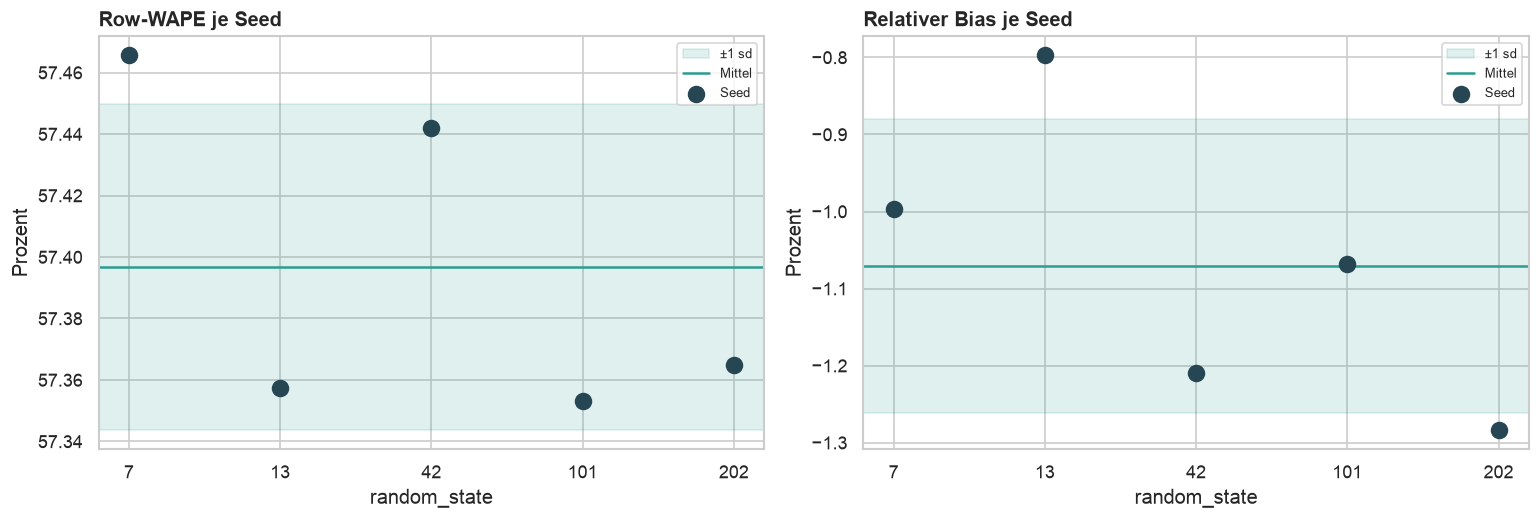

In [3]:
CLAIMS = [
    ("06_01 raw temperature anomaly", "row", -0.115),
    ("06_02 article temperature sensitivity", "row", -0.650),
    ("07_01 Bundesland calendar fix", "row", +0.018),
    ("07_01 Bundesland calendar fix", "bias", -0.543),
    ("06_01 + 06_02 cumulative weather", "row", -0.765),
]
rows = []
for label, metric, effect in CLAIMS:
    sd = summary.loc[metric, "sd"]
    rows.append({
        "batch": label,
        "metric": metric,
        "claimed effect (pp)": effect,
        "seed sd (pp)": sd,
        "effect / sd": effect / sd if sd else np.nan,
        "verdict": (
            "clear" if abs(effect) > 3 * sd
            else "suggestive" if abs(effect) > 2 * sd
            else "not separable from noise"
        ),
    })
display(pd.DataFrame(rows).style.hide(axis="index").format({
    "claimed effect (pp)": "{:+.3f}", "seed sd (pp)": "{:.4f}", "effect / sd": "{:+.1f}",
}))

figure, axes = plt.subplots(1, 2, figsize=(13, 4.5))
for axis, metric, title in zip(
    axes, ["row", "bias"], ["Row-WAPE je Seed", "Relativer Bias je Seed"]
):
    axis.axhspan(
        per_seed[metric].mean() - per_seed[metric].std(ddof=1),
        per_seed[metric].mean() + per_seed[metric].std(ddof=1),
        color="#2A9D8F", alpha=0.15, label="±1 sd",
    )
    axis.axhline(per_seed[metric].mean(), color="#2A9D8F", linewidth=1.5, label="Mittel")
    axis.scatter(
        per_seed.index.astype(str), per_seed[metric],
        s=90, color="#264653", zorder=3, label="Seed",
    )
    axis.set_xlabel("random_state")
    axis.set_ylabel("Prozent")
    axis.set_title(title, loc="left", weight="bold")
    axis.legend(fontsize=8)
figure.tight_layout()
plt.show()

## Where does the variation live?

If the seeds disagree uniformly across origins the noise is diffuse; if a few origins carry
it, the aggregate metric is hostage to those weeks.

In [4]:
origin_rows = []
for seed, frame in runs.items():
    for origin, group in frame.groupby("origin"):
        origin_rows.append({
            "seed": seed, "origin": origin.date(),
            "wape": (group.forecast - group.actual).abs().sum() / group.actual.sum() * 100,
        })
by_origin = pd.DataFrame(origin_rows).pivot(index="origin", columns="seed", values="wape")
by_origin["sd"] = by_origin.std(axis=1, ddof=1)
by_origin["range"] = by_origin.max(axis=1) - by_origin.min(axis=1)
display(by_origin.style.format("{:.2f}").set_caption("Row WAPE per origin and seed"))
display(Markdown(
    f"**Per-origin seed sd:** median {by_origin['sd'].median():.3f} pp, "
    f"max {by_origin['sd'].max():.3f} pp "
    f"(origin {by_origin['sd'].idxmax()}). The pooled row-WAPE sd is "
    f"{summary.loc['row', 'sd']:.3f} pp — far smaller, because independent per-origin "
    "wobble partly cancels when the origins are pooled."
))

# do individual forecasts move a lot even when the aggregate does not?
seeds = sorted(runs)
keys = ["ARTIKEL_ID", "MARKT_ID", "origin", "period"]
pair = runs[seeds[0]][keys + ["actual", "forecast"]].merge(
    runs[seeds[1]][keys + ["forecast"]], on=keys, suffixes=("_a", "_b")
)
disagreement = (pair.forecast_a - pair.forecast_b).abs().sum() / pair.actual.sum() * 100
display(Markdown(
    f"**Row-level disagreement between two seeds:** {disagreement:.2f}% of total volume, "
    f"against a row WAPE of about {summary.loc['row', 'mean']:.1f}%. Individual forecasts "
    "move substantially between seeds even though the pooled metrics barely do — the "
    "aggregate is stable because the disagreements are close to unbiased, not because the "
    "model is deterministic."
))

seed,7,13,42,101,202,sd,range
origin,,,,,,,
2026-03-02,55.94,55.41,55.63,55.73,56.06,0.26,55.81
2026-03-09,61.10,60.61,60.93,60.65,60.22,0.34,60.76
2026-03-16,57.81,56.38,57.49,56.93,57.20,0.55,57.26
2026-03-23,62.66,61.63,62.05,61.73,61.98,0.40,62.26
2026-03-30,48.60,48.22,48.71,48.85,48.39,0.25,48.60
2026-04-06,58.47,58.78,58.53,58.59,58.12,0.24,58.54
2026-04-13,67.30,68.59,67.63,68.95,67.75,0.70,68.26
2026-04-20,58.17,58.30,58.43,57.41,58.01,0.40,58.03
2026-04-27,54.68,54.61,54.61,54.52,55.96,0.61,55.35


**Per-origin seed sd:** median 0.320 pp, max 0.751 pp (origin 2026-05-11). The pooled row-WAPE sd is 0.053 pp — far smaller, because independent per-origin wobble partly cancels when the origins are pooled.

**Row-level disagreement between two seeds:** 6.16% of total volume, against a row WAPE of about 57.4%. Individual forecasts move substantially between seeds even though the pooled metrics barely do — the aggregate is stable because the disagreements are close to unbiased, not because the model is deterministic.

## Conclusions

**The WAPE noise floor is small — 0.053 pp at row grain — but the bias floor is nearly four
times larger at 0.19 pp. That combination reverses two judgements made earlier in the
series.**

### The measured floor

Five identical fits, differing only in `random_state`:

| Metric | Mean | **sd** | Range | 95% interval width |
| --- | ---: | ---: | ---: | ---: |
| row (article-store-day) | 57.3967 | **0.0531** | 0.1124 | 0.208 |
| article-store-week | 37.0965 | 0.0503 | 0.1219 | 0.197 |
| article-day | 23.9107 | 0.0449 | 0.0884 | 0.176 |
| **relative bias** | −1.0709 | **0.1905** | 0.4871 | 0.747 |

WAPE is far more reproducible than bias. A batch that moves row WAPE by 0.2 pp has done
something real; a batch that moves bias by 0.2 pp has done nothing measurable.

### Verdicts on the claimed effects

| Batch | Metric | Effect | effect / sd | Verdict |
| --- | --- | ---: | ---: | --- |
| `06_02` article sensitivity | row | −0.650 | **−12.3** | **clear** |
| `06_01`+`06_02` cumulative | row | −0.765 | **−14.4** | **clear** |
| `07_01` Bundesland fix | bias | −0.543 | −2.9 | suggestive |
| `06_01` raw anomaly | row | −0.115 | −2.2 | suggestive |
| `07_01` Bundesland fix | row | +0.018 | +0.3 | not separable |

### Two earlier judgements were wrong, and both were wrong in the cautious direction

**1. `06_01` was under-credited.** That notebook concluded its −0.115 pp was "not
separable from noise", reasoning from the ±5 pp gain-share reshuffle on unrelated features.
That inference does not hold: **importance churn does not imply WAPE instability.** The
boosters reallocate splits freely among correlated features while producing nearly the same
predictions in aggregate. At 2.2 sd the effect is suggestive, not null. `06_01`'s
conclusion should be softened from "not separable from noise" to "small but probably real".

**2. `07_01`'s bias movement was too quickly dismissed.** That notebook argued the
−0.543 pp bias change was "within run-to-run variation". Against a bias sd of 0.1905 — and
allowing sd×√2 ≈ 0.269 for a difference of two independent fits — it sits at roughly 2.0 sd.
Corroborating this: the five-seed mean bias on fixed data is **−1.071**, against −0.605 for
the single baseline-data fit. **The data fix probably did shift bias downward**, and
`07_01`'s conclusion #2 should be restated accordingly. The fix remains correct on
correctness grounds, but it is not bias-neutral.

The reassuring part is that the headline result of the series is untouched: `06_02` at
12 sd and the cumulative weather programme at 14 sd are not close to the noise.

### Where the variation lives

**Per-origin seed sd: median 0.320 pp, max 0.751 pp** (2026-05-11) — six times the pooled
sd of 0.053. The aggregate is stable only because independent per-origin wobble cancels
when the origins are pooled. **Single-origin comparisons are therefore not interpretable at
all** below about 1 pp — which retrospectively undermines several per-origin mechanism
claims made in `06_01`, `06_02` and `07_01`, including "origin X improved by 0.3 pp".
Per-origin evidence should be read as a *pattern across many origins* (as the warm/cold
split in `06_02` was), never as individual weeks.

**Row-level disagreement between two seeds is 6.16% of volume**, against a row WAPE of
57.4%. Individual forecasts move a great deal between seeds; the pooled metric is steady
because those disagreements are close to unbiased, not because the model is deterministic.
Any claim about a specific article-store-day is meaningless.

### Practical rules for the remaining work

1. **Report row WAPE to two decimals, bias to one.** The third decimal on WAPE and the
   second on bias are noise.
2. **Treat 0.15 pp as the significance threshold for row WAPE** (≈3 sd) and **0.6 pp for
   bias**. Anything smaller needs repeated seeds before it is claimed.
3. **Never interpret a single origin.** Median per-origin sd is 0.32 pp.
4. **Do not infer WAPE instability from importance churn.** Measured here to be unrelated.
5. Future batches with expected effects under ~0.2 pp should be run at 3 seeds from the
   start; at ~25 min per fit that is cheaper than an unresolvable result.

### Operational note

Fit times varied wildly across the five runs — 1,350 s and 1,281 s for seeds 7 and 13, then
12,217 s and 14,603 s for seeds 101 and 202, on identical work. That is machine contention,
not a property of the seeds, but it should be budgeted for: a nominally 25-minute fit can
take four hours.